In [ ]:
import numpy as np
import pandas as pd
from pandas import Timedelta
from functools import reduce
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from scipy import signal
%matplotlib inline

NF_ORANGE = '#ff5a36'
NF_BLUE = '#163251'

In [2]:
# Loading the raw final DataFrame
df = pd.read_csv(r'..\..\data_cleaned\merged\02_4_clean_data.csv')

In [3]:
# Converting date columns to datetime and filtering for 2019-2024 period

df['date'] = pd.to_datetime(df['date'])
df['period_start_utc'] = pd.to_datetime(df['period_start_utc'])

start_date_df = '2019-01-01'
end_date_df = '2024-12-31'
df = df.query("date >= @start_date_df")
df = df.query("date <= @end_date_df")
df['load_forecast_da'].isna().sum()
df.columns

Index(['date', 'year', 'month', 'day', 'dayofyear', 'hour', 'dayofweek',
       'price', 'period_start_utc', 'period_end_utc', 'load_forecast_da',
       'off_wind_da', 'on_wind_da', 'solar_da', 'gen_forecast_da',
       'res_sum_da', 'dayofyear_sin1', 'dayofyear_cos1', 'hour_sin1',
       'hour_cos1', 'dayofweek_sin1', 'dayofweek_cos1', 'is_holiday',
       'day_type', 'price_gas'],
      dtype='object')

In [4]:
# Ensure timestamp index
df.set_index('period_start_utc', inplace=True)

Text(0.5, 1.0, 'Day-Ahead Energy Prices in 2019-2024')

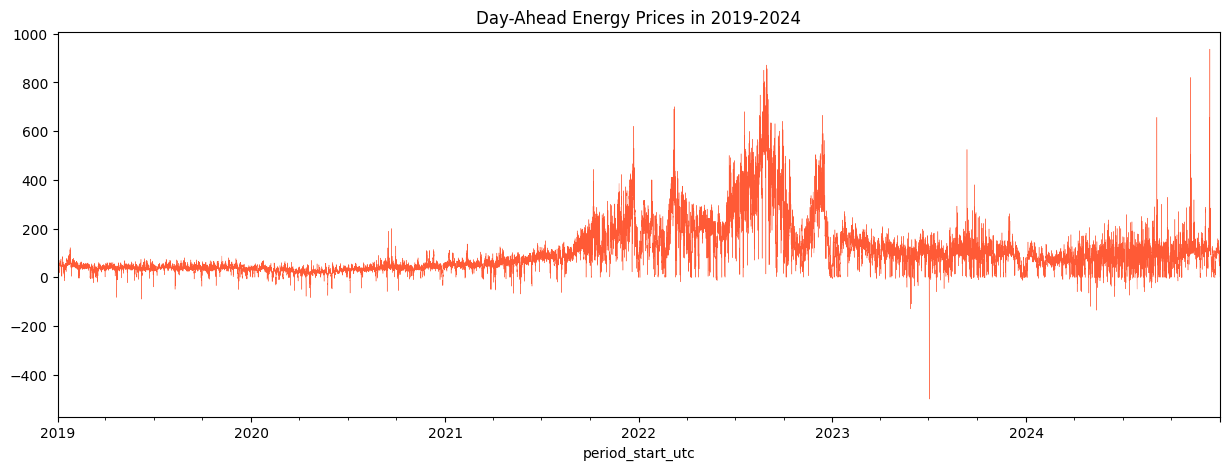

In [5]:
df['price'].plot(figsize=(15, 5), color=NF_ORANGE, linewidth=0.3)
plt.title('Day-Ahead Energy Prices in 2019-2024')

## LSTM (last layer has only 1 output neuron)

In [6]:
# 2. Add residual_load = load - RES and dummies for a year

df["residual_load"] = (
    df["load_forecast_da"]
    - df["off_wind_da"]
    - df["on_wind_da"]
    - df["solar_da"]
)

df["year"] = df["date"].dt.year
df = pd.get_dummies(df, columns=["year"], drop_first=True, dtype=int)
df["year_2025"] = 0  # Adding a dummy column for 2025 with all values set to 0
df["year_2026"] = 0  # Adding a dummy column for 2026 with all values set to 0
df.columns

Index(['date', 'month', 'day', 'dayofyear', 'hour', 'dayofweek', 'price',
       'period_end_utc', 'load_forecast_da', 'off_wind_da', 'on_wind_da',
       'solar_da', 'gen_forecast_da', 'res_sum_da', 'dayofyear_sin1',
       'dayofyear_cos1', 'hour_sin1', 'hour_cos1', 'dayofweek_sin1',
       'dayofweek_cos1', 'is_holiday', 'day_type', 'price_gas',
       'residual_load', 'year_2020', 'year_2021', 'year_2022', 'year_2023',
       'year_2024', 'year_2025', 'year_2026'],
      dtype='object')

In [7]:
# LSTM requires normalized inputs.

target = "price"
features = ['price_gas', 'load_forecast_da', 'off_wind_da', 'on_wind_da',
       'solar_da', 'gen_forecast_da', 'dayofyear_sin1',
       'dayofyear_cos1', 'hour_sin1', 'hour_cos1', 'dayofweek_sin1',
       'dayofweek_cos1', 'is_holiday', 'year_2020', 'year_2021', 'year_2022', 'year_2023',
       'year_2024', 'year_2025', 'year_2026']
features_to_scale = ['price_gas', 'load_forecast_da', 'off_wind_da', 'on_wind_da',
       'solar_da', 'gen_forecast_da']

# Set feature_range to (-1, 1)
price_scaler = MinMaxScaler(feature_range=(-1, 1))
exog_scaler  = MinMaxScaler(feature_range=(-1, 1))

# Combine target and features into one list
all_cols = [target] + features

# Create 'scaled' as a copy of only those columns from df
# This automatically preserves the original index
scaled = df[all_cols].copy()

# Fit and transform the target and features separately:
scaled['price'] = price_scaler.fit_transform(df[[target]])
scaled[features_to_scale] = exog_scaler.fit_transform(df[features_to_scale])

print (len(scaled))
scaled.head()

52608


,price,price_gas,load_forecast_da,off_wind_da,on_wind_da,solar_da,gen_forecast_da,dayofyear_sin1,dayofyear_cos1,hour_sin1,...,dayofweek_sin1,dayofweek_cos1,is_holiday,year_2020,year_2021,year_2022,year_2023,year_2024,year_2025,year_2026
period_start_utc,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,-0.289735,-0.889238,-0.542987,0.487854,-0.121814,-1.0,-0.081547,0.0,1.0,0.000000,...,0.781831,0.62349,1,0,0,0,0,0,0,0
2019-01-01 01:00:00+00:00,-0.309438,-0.889238,-0.589763,0.483703,-0.047615,-1.0,-0.068859,0.0,1.0,0.258819,...,0.781831,0.62349,1,0,0,0,0,0,0,0
2019-01-01 02:00:00+00:00,-0.317556,-0.889238,-0.601569,0.468677,0.024338,-1.0,-0.033890,0.0,1.0,0.500000,...,0.781831,0.62349,1,0,0,0,0,0,0,0
2019-01-01 03:00:00+00:00,-0.314075,-0.889238,-0.586701,0.447886,0.085259,-1.0,-0.005074,0.0,1.0,0.707107,...,0.781831,0.62349,1,0,0,0,0,0,0,0
2019-01-01 04:00:00+00:00,-0.321233,-0.889238,-0.574507,0.440617,0.131354,-1.0,0.009597,0.0,1.0,0.866025,...,0.781831,0.62349,1,0,0,0,0,0,0,0


In [8]:
# Create sequences (lags) - in this case our lag is 1 week, i.e. 168 hours

# Turning DataFrame into Numpy array
data_scaled = scaled.values

# Defining function to create sequence cubes (number_of_rows, lookback=168, number_of_features=19)
def create_sequences(data, lookback=168):
    X, y = [], []
    
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i, 0])   # price is first column
    
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, lookback=168)


In [9]:
X.shape
#y.shape

(52440, 168, 21)

In [10]:
# Building the LSTM model

model = Sequential()

model.add(LSTM(64, return_sequences=True,
               input_shape=(X.shape[1], X.shape[2])))

model.add(Dropout(0.2))

model.add(LSTM(32))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 168, 64)           22016     
                                                                 
 dropout (Dropout)           (None, 168, 64)           0         
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 34465 (134.63 KB)
Trainable params: 34465 (134.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [11]:
# Train the model
history = model.fit(
    X, y,
    epochs=20,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/20

738/738 [==============================] - 148s 191ms/step - loss: 0.0023 - val_loss: 0.0027
Epoch 2/20
738/738 [==============================] - 136s 184ms/step - loss: 0.0010 - val_loss: 0.0024
Epoch 3/20
738/738 [==============================] - 150s 204ms/step - loss: 7.9981e-04 - val_loss: 0.0022
Epoch 4/20
738/738 [==============================] - 157s 213ms/step - loss: 6.7218e-04 - val_loss: 0.0018
Epoch 5/20
738/738 [==============================] - 144s 195ms/step - loss: 5.4809e-04 - val_loss: 0.0015
Epoch 6/20
738/738 [==============================] - 145s 197ms/step - loss: 4.5871e-04 - val_loss: 0.0012
Epoch 7/20
738/738 [==============================] - 150s 203ms/step - loss: 3.9760e-04 - val_loss: 0.0011
Epoch 8/20
738/738 [==============================] - 147s 199ms/step - loss: 3.7403e-04 - val_loss: 9.8574e-04
Epoch 9/20
738/738 [==============================] - 146s 198ms/step - loss: 3.5774e-04 - val_loss: 9.7152e-04
Epoch 10/20
738/738 [======

Text(0.5, 1.0, 'Day-Ahead Energy Prices in 2025')

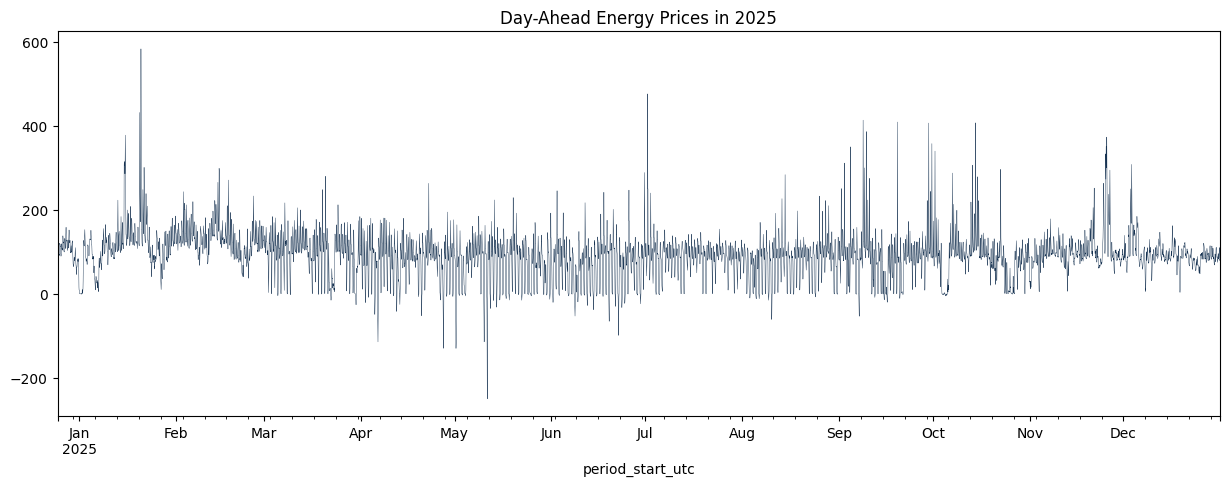

In [25]:
# Preparing test data for evaluation
# Loading the raw final DataFrame
df_test = pd.read_csv(r'..\..\data_cleaned\merged\02_4_clean_data.csv')
df_test['date'] = pd.to_datetime(df_test['date'])
df_test['period_start_utc'] = pd.to_datetime(df_test['period_start_utc'])

start_date_df_test = '2024-12-25'
end_date_df_test = '2025-12-31'
df_test = df_test.query("date >= @start_date_df_test")
df_test = df_test.query("date <= @end_date_df_test")
df_test.set_index('period_start_utc', inplace=True)

df_test['price'].plot(figsize=(15, 5), color=NF_BLUE, linewidth=0.3)
plt.title('Day-Ahead Energy Prices in 2025')

In [26]:
df_test["year"] = df_test["date"].dt.year
df_test = pd.get_dummies(df_test, columns=["year"], dtype=int)
df_test.columns

Index(['date', 'month', 'day', 'dayofyear', 'hour', 'dayofweek', 'price',
       'period_end_utc', 'load_forecast_da', 'off_wind_da', 'on_wind_da',
       'solar_da', 'gen_forecast_da', 'res_sum_da', 'dayofyear_sin1',
       'dayofyear_cos1', 'hour_sin1', 'hour_cos1', 'dayofweek_sin1',
       'dayofweek_cos1', 'is_holiday', 'day_type', 'price_gas', 'year_2024',
       'year_2025'],
      dtype='object')

In [27]:
# Adding year columns with dummies for 2019-2024
# List of the dummy columns needed
year_dummies = ['year_2020', 'year_2021', 'year_2022', 'year_2023', 'year_2026']

# Assign 0 to all of them at once
df_test[year_dummies] = 0

In [28]:
# LSTM TEST requires normalized inputs.

target_test = "price"
features_test = ['price_gas', 'load_forecast_da', 'off_wind_da', 'on_wind_da',
       'solar_da', 'gen_forecast_da', 'dayofyear_sin1',
       'dayofyear_cos1', 'hour_sin1', 'hour_cos1', 'dayofweek_sin1',
       'dayofweek_cos1', 'is_holiday', 'year_2020', 'year_2021', 'year_2022', 'year_2023',
       'year_2024', 'year_2025', 'year_2026']
features_to_scale_test = ['price_gas', 'load_forecast_da', 'off_wind_da', 'on_wind_da',
       'solar_da', 'gen_forecast_da']

# Set feature_range to (-1, 1)
price_scaler_test = MinMaxScaler(feature_range=(-1, 1))
exog_scaler_test  = MinMaxScaler(feature_range=(-1, 1))

# Combine target and features into one list
all_cols_test = [target_test] + features_test

# Create 'scaled' as a copy of only those columns from df_test that we need for testing
# This automatically preserves the original index
scaled_test = df_test[all_cols_test].copy()

# Fit and transform the target and features separately:
scaled_test['price'] = price_scaler_test.fit_transform(df_test[[target_test]])
scaled_test[features_to_scale_test] = exog_scaler_test.fit_transform(df_test[features_to_scale_test])

print (len(scaled_test))
scaled_test.head()

8927


,price,price_gas,load_forecast_da,off_wind_da,on_wind_da,solar_da,gen_forecast_da,dayofyear_sin1,dayofyear_cos1,hour_sin1,...,dayofweek_sin1,dayofweek_cos1,is_holiday,year_2020,year_2021,year_2022,year_2023,year_2024,year_2025,year_2026
period_start_utc,,,,,,,,,,,,,,,,,,,,,
2024-12-25 00:00:00+00:00,-0.192151,0.243485,-0.769469,-0.472489,-0.617965,-1.0,-0.660129,-0.107308,0.994226,0.000000,...,0.974928,-0.222521,1,0,0,0,0,1,0,0
2024-12-25 01:00:00+00:00,-0.195437,0.243485,-0.822847,-0.455355,-0.633706,-1.0,-0.701897,-0.107308,0.994226,0.258819,...,0.974928,-0.222521,1,0,0,0,0,1,0,0
2024-12-25 02:00:00+00:00,-0.205657,0.243485,-0.855855,-0.456614,-0.650756,-1.0,-0.759015,-0.107308,0.994226,0.500000,...,0.974928,-0.222521,1,0,0,0,0,1,0,0
2024-12-25 03:00:00+00:00,-0.217219,0.243485,-0.860081,-0.459079,-0.670396,-1.0,-0.775420,-0.107308,0.994226,0.707107,...,0.974928,-0.222521,1,0,0,0,0,1,0,0
2024-12-25 04:00:00+00:00,-0.205657,0.243485,-0.814786,-0.446878,-0.691218,-1.0,-0.743621,-0.107308,0.994226,0.866025,...,0.974928,-0.222521,1,0,0,0,0,1,0,0


In [43]:
# Creating the loop that will take the last 168 hours of 2024,
# predict the next hour, then slide the window forward by one hour and repeat for 24 hours of 2025

# 1. Convert your DataFrame to a NumPy array for the model
# We select all 21 columns in the order they appear in your list
all_features = scaled_test.to_numpy() 

# 2. Extract the "Seed" window (the last 168 hours of 2024)
# In your DF, this would be the first 168 rows if it starts on 25-12-2024
# data_scaled[-lookback:] means "take the last 168 rows"
current_window = all_features[:168].copy() 

# 3. Prepare your Exogenous inputs for 2025
# We need rows from 168 onwards, and columns index 1 to 20 (skipping 'price')
exog_forecasts = all_features[168:, 1:] 

future_predictions = []

# n is the number of 2025 hours you want to predict
n = 1354 # Prediction horizon in hours

for i in range(n):
    # Reshape current_window to (1, 168, 21) for the LSTM
    input_data = current_window.reshape(1, 168, 21)
    
    # Predict the price for the next hour
    y_pred = model.predict(input_data, verbose=0)
    
    # Store the prediction
    future_predictions.append(y_pred[0, 0])
    
    # --- Build the row for the next step ---
    # Current exogenous features for the hour we just predicted
    next_exog = exog_forecasts[i] 
    
    # Combine [Predicted Price] + [Actual Exogenous Data]
    new_row = np.hstack([y_pred[0], next_exog]) 
    
    # Slide the window forward
    current_window = np.vstack([current_window[1:], new_row])

# 4. Final step: Inverse Scale
future_predictions = np.array(future_predictions).reshape(-1, 1)
final_prices = price_scaler_test.inverse_transform(future_predictions)

Text(0.5, 1.0, 'Predicted vs Actual Day-Ahead Prices for 2025')

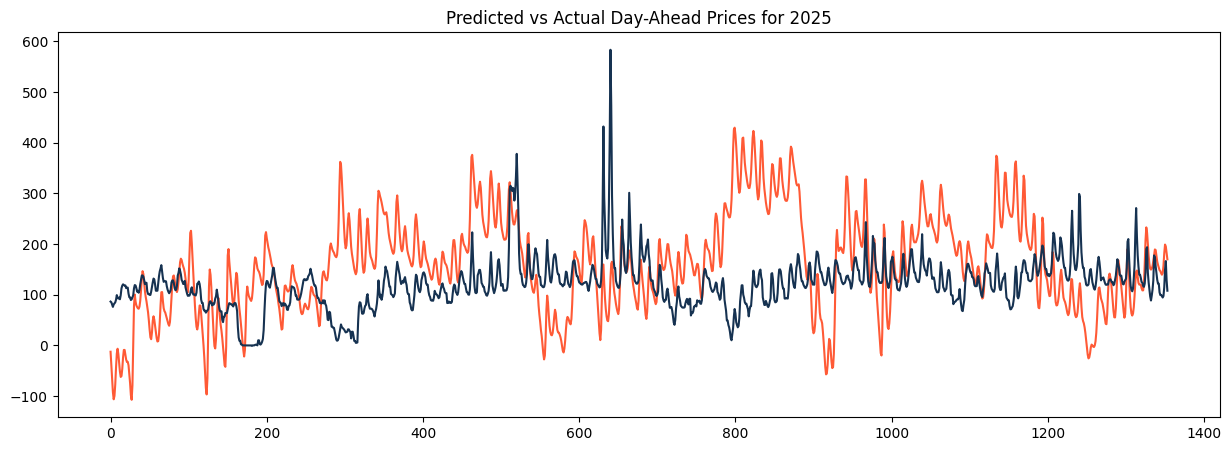

In [44]:
plt.figure(figsize=(15,5))
plt.plot(final_prices, label='Predicted Prices for 2025', color=NF_ORANGE)
plt.plot(df_test['price'].values[:1354], label='Actual Prices for 2025', color=NF_BLUE)
plt.title('Predicted vs Actual Day-Ahead Prices for 2025')

In [46]:
# Assessing the models with RMSE, MAPE and MAE

rms_lstm = np.sqrt(mean_squared_error(df_test['price'].values[:1354], final_prices))

mape_lstm = mean_absolute_percentage_error(df_test['price'].values[:1354], final_prices) * 100

mae_lstm = np.mean(np.abs(df_test['price'].values[:1354] - final_prices))



# Printing RMSE of all the methods
print("RMSE: ", round(rms_lstm,3))
print("MAE: ", round(mae_lstm,3))

RMSE:  111.952
MAE:  90.904
